# Mathematics and Computational Methods for Complex Systems
## Problem Set – Linear Algebra & Transformations

This notebook contains computational solutions to problem sets from the
*Mathematics and Computational Methods for Complex Systems* course.

The focus is on:
- Matrix transformations
- Eigenvalues and eigenvectors
- Linear independence
- Numerical verification using Python


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import odeint

# Question 1

### Question 1A: Matrix Definition
We define the matrix \( A \) and analyse its properties using eigenvalues
and eigenvectors.

In [ ]:
A= np.array([[2,4,6],[8,10,12],[14,16,18]])

list =[1,2,3]

#function for calculating A+A^T
def my_transf(A):
    transpose_A=np.transpose(A)
    sum_of_a_matrix=A+transpose_A
    return sum_of_a_matrix

final_result=my_transf(A)
print("Sum of the matrix and its transpose:")
print(final_result)

Sum of the matrix and its transpose:
[[ 4 12 20]
 [12 20 28]
 [20 28 36]]


# 1B

In [ ]:
# function for computing the dot product of the i-th and j-th eigenvectors of a given square matrix A.
def eigprod(A, i, j):
    """
    Calculate the dot product of the i-th and j-th eigenvectors of a square matrix A.

    Parameters:
    A (ndarray): A square matrix.
    i (int): Index of the first eigenvector.
    j (int): Index of the second eigenvector.

    Returns:
    float: The dot product of the i-th and j-th eigenvectors.
    """
    eigenvals, eigenvecs = np.linalg.eig(A)
    return np.dot(eigenvecs[:, i], eigenvecs[:, j])

result = eigprod(A, 0, 1)
print(f"The dot product of the 0th and 1st eigenvectors is: {result}")


The dot product of the 0th and 1st eigenvectors is: -0.2734343708098653


# 1C

In [ ]:
# Function to calculate the transformation of a matrix
def my_transf(matrix):
    return np.transpose(matrix) + 2 * matrix

# Function to compute the product of eigenvalues at indices i and j
def eigenprod(matrix, i, j):
    eigenvalues, _ = np.linalg.eig(matrix)
    return eigenvalues[i - 1] * eigenvalues[j - 1]

# random seed for reproducibility
np.random.seed(123)

# Generate a random A 4x4 matrix
A_ran = np.random.rand(4, 4)

i = 1
j = 3

result = eigenprod(my_transf(A_ran), i, j)


print("Matrix A:")
print(A_ran)
print(f"Dot Product of eigenvectors {i} and {j}: {result}")


Matrix A:
[[0.69646919 0.28613933 0.22685145 0.55131477]
 [0.71946897 0.42310646 0.9807642  0.68482974]
 [0.4809319  0.39211752 0.34317802 0.72904971]
 [0.43857224 0.0596779  0.39804426 0.73799541]]
Dot Product of eigenvectors 1 and 3: (4.804864985942626+0.1826156291939331j)


# 1D

In [ ]:
# Define vectors v2 and v3
v2 = np.array([2, 4, 6])
v3 = np.array([4, 8, 12])

# matrix R
R = np.array([
    [1, 1, 3],
    [2, 3, 1],
    [1, 3, 2]
])

# Compute R^T - R
R_diff = R.T - R

# Compute the expression v2^T (R^T - R) v3
result = np.dot(np.dot(v2.T, R_diff), v3)

print("Matrix R:")
print(R)
print("\nMatrix R^T - R (Skew-Symmetric Part):")
print(R_diff)
print("\nResult of v2^T (R^T - R) v3:")
print(result)


Matrix R:
[[1 1 3]
 [2 3 1]
 [1 3 2]]

Matrix R^T - R (Skew-Symmetric Part):
[[ 0  1 -2]
 [-1  0  2]
 [ 2 -2  0]]

Result of v2^T (R^T - R) v3:
0


# 1E

In [ ]:
eigenvals, eigenvecs = np.linalg.eig(A_ran)
# Check linear dependency of eigenvectors
# Choose v1 and check if it can be expressed as a linear combination of the others
v1 = eigenvecs[:, 0]  # First eigenvector
other_vectors = eigenvecs[:, 1:]  # Remaining eigenvectors

# Solve for weights g_i such that v1 = g_2*v2 + g_3*v3 + ...
weights, residuals, rank, s = np.linalg.lstsq(other_vectors, v1, rcond=None)

# Reconstruct v1 using the computed weights
reconstructed_v1 = np.dot(other_vectors, weights)

# Check if v1 and reconstructed_v1 are close
is_dependent = np.allclose(v1, reconstructed_v1)


print("\nEigenvalues of Transformed Matrix:")
print(eigenvals)
print("\nEigenvectors of Transformed Matrix:")
print(eigenvecs)
print("\nWeights (g_i) for Linear Combination of Other Eigenvectors:")
print(weights)
print("\nIs v1 linearly dependent on the other eigenvectors?")
print(is_dependent)


Eigenvalues of Transformed Matrix:
[ 1.89220444  0.32163565  0.29949351 -0.31258453]

Eigenvectors of Transformed Matrix:
[[-0.41920348  0.54277402  0.67223065  0.22793883]
 [-0.68763394  0.53624339  0.36762863 -0.73729324]
 [-0.47263312 -0.00229162 -0.09576677  0.57522606]
 [-0.35783506 -0.64640092 -0.6354399  -0.27121493]]

Weights (g_i) for Linear Combination of Other Eigenvectors:
[-1.96067068  1.6457619   0.04608423]

Is v1 linearly dependent on the other eigenvectors?
False


The eigenvectors of
my_transf
(
𝐴_ran
)are **linearly independent**. This can be proven by contradiction.

Assume the opposite: suppose one eigenvector
𝑣
1
​can be written as a linear combination of the other eigenvectors
𝑣
2
,
𝑣
3
,
…
,
𝑣
𝑛
. Mathematically, this would mean:

𝑣
1 =
𝑔
2
𝑣
2
+
𝑔
3
𝑣
3
+
⋯
+
𝑔
𝑛
𝑣
𝑛
,
where
𝑔
2
,
𝑔
3
,
…
,
𝑔
𝑛 are scalar weights.

Due to the orthogonality property of eigenvectors of symmetric matrices (like
my_transf
(
𝐴_ran
)), the dot product of
𝑣
1
​
  with any other eigenvector
𝑣
𝑗

​
  (
𝑗
≠
1
=1) must be zero:

𝑣
1
⋅
𝑣
𝑗 = 0
However, this contradicts the assumption of linear dependence because, in a non-trivial linear combination,
𝑣
1 cannot simultaneously have a zero dot product with all its constituent vectors. Such a scenario would violate the mathematical definition of linear dependence.

Therefore, the eigenvectors of
my_transf
(
𝐴_ran
)
cannot be written as linear combinations of one another, and they must be **linearly independent**.



# 1F

The eigenvectors of
my_transf
(
𝐴_ran
)are linearly independent, they form a basis for the vector space they span. The dimension of a vector space is determined by the number of vectors in its basis. In this case, since
my_transf
(
𝐴_ran
)is an
𝑛
×
𝑛 matrix, it has
𝑛
eigenvectors. Therefore, the dimension of the spanned space is
𝑛, matching the number of eigenvectors.

This means that these eigenvectors, acting as a complete set of independent directions, define an
𝑛-dimensional vector space.

# 1G

In [ ]:
# function for checking if the vectors form a basis
def function(angle):
    # Define the vectors
    vec1 = [math.cos(angle)**2, 2, -1]
    vec2 = [math.sin(angle)**2, -2, 1]
    vec3 = [1, 6, -3]

    matrix = np.column_stack((vec1, vec2, vec3))

    rank_matrix = np.linalg.matrix_rank(matrix)

    return rank_matrix == 3

# Example usage with angle in radians
angle = 2  # Radians
result = function(angle)

# Print the result
print(f"Do the vectors form a basis for R^3 at angle {angle} radians? {result}")


Do the vectors form a basis for R^3 at angle 2 radians? False


# Question 2

# 2A

In [ ]:
def remain_prob():
    total_prob = 1  # Initialize total probability
    for i in range(1, 100):  # Loop from 1 to 100
        overuse_fault = 0.0001 * i**2 / (1 + i)  # overuse fault probability
        factory_fault = 0.01 * (1 + (1 - i) / (1 + i))  # factory fault probability
        fault_prob = overuse_fault + factory_fault
        total_prob *= (1 - fault_prob)  # Update total survival probability
    return total_prob

# Compute probability
probability = remain_prob()

print(f"Probability of surviving 100 months without a fault: {probability}")


Probability of surviving 100 months without a fault: 0.5648590973579708


The total survival probability over 100 months is:

$$
\text{total\_prob} = \prod_{i=1}^{100} \left( 1 - \text{fault\_prob} \right)
$$

Where:

$$
\text{fault\_prob} = \text{overuse\_fault} + \text{factory\_fault}
$$

The probabilities for faults are defined as:

$$
\text{overuse\_fault} = \frac{0.0001 \cdot i^2}{1 + i}
$$

$$
\text{factory\_fault} = 0.01 \cdot \left( 1 + \frac{1 - i}{1 + i} \right)
$$
{1 + i} \right)
\]
{1 + i} \right)
\]
{1 + i} \right)
\]


# 2B

[100.  99.  98.  98.  98.  98.  98.  98.  98.  98.  97.  96.  96.  96.
  96.  95.  95.  95.  95.  95.  95.  94.  94.  94.  93.  93.  93.  93.
  93.  93.  93.  93.  93.  93.  92.  92.  92.  91.  91.  91.  91.  91.
  91.  91.  91.  90.  89.  89.  89.  89.  89.  88.  87.  87.  85.  85.
  84.  83.  83.  81.  81.  81.  81.  79.  79.  78.  77.  77.  77.  76.
  75.  74.  74.  74.  73.  73.  72.  71.  70.  68.  68.  68.  68.  68.
  68.  68.  66.  66.  66.  66.  66.  66.  66.  64.  63.  63.  62.  61.
  61.  61.]


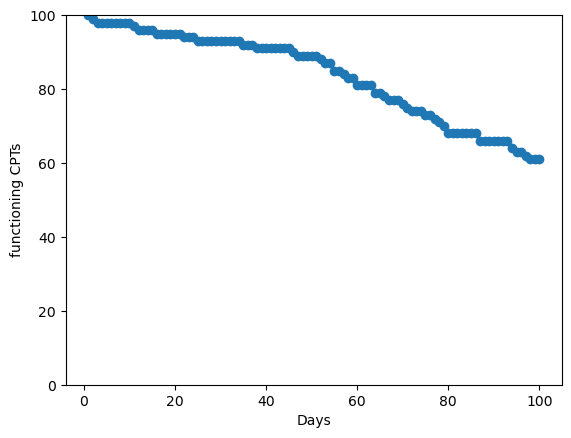

In [ ]:
def factor_stimulation(n0):
    v = np.zeros(100)
    for i in range (100):
        overuse_fault=0.0001*(i+1)**2/(1+(i+1))
        factory_fault=0.01*(1+ (1-(i+1))/(1+(i+1)))
        overuse_faults=np.random.binomial(n0,overuse_fault)
        factory_failure=np.random.binomial(n0,factory_fault)
        n0-=(overuse_faults + factory_failure)
        v[i]=n0

    return v


a=factor_stimulation(n0=100)
print(a)

plt.scatter(range(1,101),a)
plt.xlabel("Days")
plt.ylabel("functioning CPTs")
plt.ylim(0,100)
plt.show()



# 2C

In [ ]:
def profit(x, y):

    total_surviving_prob = 1.0

    # Loop through months 1 to 100
    for i in range(1, 101):

        factory_failure_prob = 0.01 * (1 + (1 - i) / (1 + i))
        factory_failure_prob *= (1 - 20 * x)
        overuse_fault_prob = 0.0001 * (i**2 / (1 + i))
        overuse_fault_prob *= (1 - 20 * y)
        surviving_prob = 1.0 - (factory_failure_prob + overuse_fault_prob)
        total_surviving_prob *= surviving_prob

    total_profit = 100 * 5.0 * total_surviving_prob - 100 * (x + y)
    return total_profit

# Example usage
x = 0.01
y = 0.02
# Calculate profit
a = profit(x, y)
print(f"Profit for x = {x}, y = {y}: {round(a, 2)}")


Profit for x = 0.01, y = 0.02: 344.04


# 2D

To maximize the profit function \( p(x, y) \) under the constraint \( x + y = 0.1 \), the factory must allocate investments \( x \) and \( y \) such that the total investment per CPT remains fixed at 10 pence. The optimization problem involves finding the values of \( x \) (investment in reducing factory faults) and \( y \) (investment in reducing overuse faults) that maximize \( p(x, y) \), while ensuring the constraint \( x + y = 0.1 \) holds.

Using the method of Lagrange multipliers, the condition for a locally optimal allocation is that the gradient of \( p(x, y) \) is proportional to the gradient of the constraint \( x + y - 0.1 = 0 \). Mathematically, this means the gradients must satisfy:

$$
\frac{\partial p}{\partial x} = \frac{\partial p}{\partial y} = \lambda,
$$

where \( \lambda \) is the Lagrange multiplier. This ensures the profit sensitivity with respect to investments in reducing factory faults and overuse faults is balanced at the optimal point.

Additionally, the solution must satisfy the constraint:

$$
x + y = 0.1,
$$

and the conditions:

$$
x \geq 0, \quad y \geq 0.
$$

This approach guarantees the most efficient allocation of resources to maximize profit.


# Question 3

# 3A

The **outcome space** represents all possible combinations of the two uncertain events in this game:
# The two uncertain events:

. **The box  the money $B_R$):**
   - The money can be in any of the three b $B_1$, $B_2$,$B_3$3 \).
   - Thus, there are 3 possible outcome$B_R$_R \)

2. **The cho$B_C$(_C \):**
   - The player can choose any of the thr     $B_1$, $B_2$,$B_3$( B_3 \).
   - Thus, there are 3 possible out$es $ \( \).

### Combining the Two Events:
Each combination of $B_R$ (box with money) and $B_C$ (chosen box) forms a distinct outcome. Since there are 3 possibilities for $B_R$ and 3 possibilities for $B_C$, the total number of outcomes is:

$$
3 \times 3 = 9
$$

3 \times 3 = 9
$$

### Outcome Space:

The outcome space \( S \) is:

$$
S = \{ (B_1, B_1), (B_1, B_2), (B_1, B_3), (B_2, B_1), (B_2, B_2), (B_2, B_3), (B_3, B_1), (B_3, B_2), (B_3, B_3) \}
$$

## Interpretati$n of Outcomes$

Each outcome \( ($_R, B_$) \) is a pair where:
- \( B_R \):$The bo$ containing the money.
- \( B_C \): The box chos$n by the play$r.

For example:
$- \( ($_1, B_1) \): The money is $n \( B$1 \),$and the playe$ chooses \( B_1 \).$
- \( $B_2, B_3) \): The money is$in \( $_2 \), and the payer chooses \( B_3 \).

### Summary:

The outcome spa$e cons$sts of$9 poss$ble combinations of \( B_R \) and \( B_C \), representing all possible scenarios. Since both events are independent and uniformly distributed, each outcome is equally likely.
ent and uniformly distributed.


# 3B

### Steps to Calculate Expected Reward and Variance

Let \( R \) be a random variable representing the reward.

#### **Expected Reward \( \mathbb{E}[R] \):**

$If \( B_C$B_R \) (the chosen box contains m then, $y), \($ X \).
2. If \( B_C \neq B_R \) (the chosen box is empty), \( R = 0 \).
3. The probability of choosing the correct box is \( \frac{1}{3} \), and the probability of choosing an incorrect box is \( \frac{2}{3} \).

Using the formula:
\[
\mathbb{E}[R] = \left(\frac{1}{3} \cdot X\right) + \left(\frac{2}{3} \cdot 0\right) = \frac{X}{3}.
\]

#### **Variance \( \text{Var}(R) \):**

1. Variance is defined as:
\[
\text{Var}(R) = \mathbb{E}[R^2] - (\mathbb{E}[R])^2
\]
2. Calculate \( \mathbb{E}[R^2] \):
   - When \( B_C = B_R \), \( R^2 = X^2 \), with \( P(R = X) = \frac{1}{3} \).
   - When \( B_C \neq B_R \), \( R^2 = 0^2 \), with \( P(R = 0) = \frac{2}{3} \).
   - Thus:
   \[
   \mathbb{E}[R^2] = \left(\frac{1}{3} \cdot X^2\right) + \left(\frac{2}{3} \cdot 0\right) = \frac{X^2}{3}.
   \]

3. Substituting into the variance formula:
\[
\text{Var}(R) = \frac{X^2}{3} - \left(\frac{X}{3}\right)^2 = \frac{X^2}{3} - \frac{X^2}{9} = \frac{2X^2}{9}.
\]

#### **Results:**

1. **Expected Reward:**
\[
\mathbb{E}[R] = \frac{X}{3}
\]

2. **Variance of the Reward:**
\[
\text{Var}(R) = \frac{2X^2}{9}
\]


In [ ]:
X = 100
expected_reward = (1/3) * X + (2/3) * 0

expected_reward_squared = (1/3) * (X**2) + (2/3) * 0

variance_reward = expected_reward_squared - (expected_reward**2)

# Print results
print(f"Amount of money in the box (X): {X}")
print(f"Expected Reward (E[R]): {expected_reward}")
print(f"Variance of Reward (Var(R)): {variance_reward}")


Amount of money in the box (X): 100
Expected Reward (E[R]): 33.33333333333333
Variance of Reward (Var(R)): 2222.222222222222


# 3C

In [ ]:
# Define the amount of money in the box (X)
X = 100  # Example value for the reward amount

# Stick Strategy
def stick_strategy(X):
    # Expected reward for Stick Strategy
    expected_reward_stick = (1/3) * X + (2/3) * 0

    # Variance for Stick Strategy
    expected_reward_squared_stick = (1/3) * (X**2) + (2/3) * 0
    variance_stick = expected_reward_squared_stick - (expected_reward_stick**2)

    return expected_reward_stick, variance_stick

# Swap Strategy
def swap_strategy(X):
    # Expected reward for Swap Strategy
    expected_reward_swap = (1/3) * 0 + (2/3) * X

    # Variance for Swap Strategy
    expected_reward_squared_swap = (1/3) * 0 + (2/3) * (X**2)
    variance_swap = expected_reward_squared_swap - (expected_reward_swap**2)

    return expected_reward_swap, variance_swap

# Compute results for Stick and Swap strategies
stick_reward, stick_variance = stick_strategy(X)
swap_reward, swap_variance = swap_strategy(X)

# Print results
print("Stick Strategy:")
print(f"Expected Reward: {stick_reward}")
print(f"Variance: {stick_variance}\n")

print("Swap Strategy:")
print(f"Expected Reward: {swap_reward}")
print(f"Variance: {swap_variance}")


Stick Strategy:
Expected Reward: 33.33333333333333
Variance: 2222.222222222222

Swap Strategy:
Expected Reward: 66.66666666666666
Variance: 2222.2222222222226


#### **Stick Strategy**

1. **Expected Reward**:
   - If the chosen box contains the money $B_C$ = $B_R$, you earn \( X \), with a probability of $ \frac{1}{3} $.
   - If the chosen box does not contain the money $B_C$ $ \neq $ $B_R$, you earn \( 0 \), with a probability of $ \frac{2}{3} $.
   - Thus, the expected reward is:
     $$
     \mathbb{E}[R_{\text{stick}}] = \frac{1}{3} \cdot X + \frac{2}{3} \cdot 0 = \frac{X}{3}.
     $$

2. **Variance**:
   - The variance is calculated as:
     $$
     \text{Var}(R_{\text{stick}}) = \mathbb{E}[R_{\text{stick}}^2] - (\mathbb{E}[R_{\text{stick}}])^2.
     $$
   - Compute $ \mathbb{E}[R_{\text{stick}}^2] $:
     $$
     \mathbb{E}[R_{\text{stick}}^2] = \frac{1}{3} \cdot X^2 + \frac{2}{3} \cdot 0^2 = \frac{X^2}{3}.
     $$
   - Substituting:
     $$
     \text{Var}(R_{\text{stick}}) = \frac{X^2}{3} - \left(\frac{X}{3}\right)^2 = \frac{X^2}{3} - \frac{X^2}{9} = \frac{2X^2}{9}.
     $$

---

#### **Swap Strategy**

1. **Expected Reward**:
   - If the chosen box contains the money $B_C$ = $B_R$, swapping gives \( 0 \), with a probability of $ \frac{1}{3} $.
   - If the chosen box does not contain the money $B_C$ $ \neq $ $B_R$, swapping gives \( X \), with a probability of $ \frac{2}{3} $.
   - Thus, the expected reward is:
     $$
     \mathbb{E}[R_{\text{swap}}] = \frac{1}{3} \cdot 0 + \frac{2}{3} \cdot X = \frac{2X}{3}.
     $$

2. **Variance**:
   - The variance is calculated as:
     $$
     \text{Var}(R_{\text{swap}}) = \mathbb{E}[R_{\text{swap}}^2] - (\mathbb{E}[R_{\text{swap}}])^2.
     $$
   - Compute $ \mathbb{E}[R_{\text{swap}}^2] $:
     $$
     \mathbb{E}[R_{\text{swap}}^2] = \frac{1}{3} \cdot 0^2 + \frac{2}{3} \cdot X^2 = \frac{2X^2}{3}.
     $$
   - Substituting:
     $$
     \text{Var}(R_{\text{swap}}) = \frac{2X^2}{3} - \left(\frac{2X}{3}\right)^2 = \frac{2X^2}{3} - \frac{4X^2}{9} = \frac{2X^2}{9}.
     $$

---

### Results:

1. **Stick Strategy**:
   - Expected Reward:
     $$
     \mathbb{E}[R_{\text{stick}}] = \frac{X}{3}.
     $$
   - Variance:
     $$
     \text{Var}(R_{\text{stick}}) = \frac{2X^2}{9}.
     $$

2. **Swap Strategy**:
   - Expected Reward:
     $$
     \mathbb{E}[R_{\text{swap}}] = \frac{2X}{3}.
     $$
   - Variance:
     $$
     \text{Var}(R_{\text{swap}}) = \frac{2X^2}{9}.
     $$


# 3D


If there are \( K \) boxes containing rewards among \( N \) total boxes, and you use the **swap strategy**, the expected reward and variance are calculated as follows:

#### **Expected Reward**:
1. If the box initially chosen contains a r $d(  (\( P = \frac{K) $ \)), swapping results in \( R = 0 \).
2. If the box initially chosen does not contain a r$r( d (\( P = \frac{N - ) $N} \)), swapping resul$ in \( $= X \).

Thus, the expected reward is:
$$
\mathbb{E}[R] = \frac{K}{N} \cdot 0 + \frac{N - K}{N} \cdot X = \frac{(N - K)X}{N}.
$$

#### **Variance**:
1. F$st, compute \( \m$hbb{E}[R^2] \):
$$
\mathbb{E}[R^2] = \frac{K}{N} \cdot 0^2 + \frac{N - K}{N} \cdot X^2 = \frac{(N - K)X^2}{N}.
$$

2. Then, calculate the variance using:
$$
\text{Var}(R) = \mathbb{E}[R^2] - (\mathbb{E}[R])$.
$$

Subst$ting $ \mathbb{E}[R] \)$nd \( \mathbb{E}[R^2] \):
$$
\text{Var}(R) = \frac{(N - K)X^2}{N} - \left(\frac{(N - K)X}{N}\right)^2.
$$

Simplify:
$$
\text{Var}(R(R) = \frac{(3 - 1) \cdot 1 \cdot 100^2}{3^2} = 2222.22.
$$


In [ ]:
# Generalized Swap Strategy for K Reward Boxes out of N Total Boxes
def generalized_swap_strategy(X, K, N):
    expected_reward = ((N - K) / N) * X
    expected_reward_squared = ((N - K) / N) * (X**2)
    variance = expected_reward_squared - (expected_reward**2)

    return expected_reward, variance

X = 100
K = 1
N = 3

general_reward, general_variance = generalized_swap_strategy(X, K, N)

print(f"Generalized Swap Strategy (K={K}, N={N}):")
print(f"Expected Reward: {general_reward}")
print(f"Variance: {general_variance}")


Generalized Swap Strategy (K=1, N=3):
Expected Reward: 66.66666666666666
Variance: 2222.2222222222226


# Question 4

# 4A

The prey population growth equation is:

$$
\dot{N}(t) = aN(t) - bN(t)P(t)
$$

To determine when prey births outstrip deaths, we require:

$$
\dot{N}(t) > 0
$$

Substituting the equation:

$$
aN(t) - bN(t)P(t) > 0
$$

Factorizing \( N(t) \), assuming \( N(t) > 0 \):

$$
N(t)(a - bP(t)) > 0
$$

This implies:

$$
a - bP(t) > 0
$$

Rearranging to solve for \( P(t) **Conclusion**: The maximum predator population for which prey births still outstrip deaths is:
\[ey births still outstrip deaths is:

$$
P_{\text{max}} = \frac{a}{b}
$$
P_{\text{max}} = \frac{a}{b}
\]
c{a}{b}
$$


# 4B

The predator population growth equation is:

$$
\dot{P}(t) = cN(t)P(t) - dP(t)
$$

To determine when the predator population is shrinking, we require:

$$
\dot{P}(t) < 0
$$

Substituting the equation:

$$
cN(t)P(t) - dP(t) < 0
$$

Factorizing \( P(t) \), assuming \( P(t) > 0 \):

$$
P(t)(cN(t) - d) < 0
$$

This implies:

$$
cN(t) - d < 0
$$

Rearranging to solve for \( N(t) \):

$$
N(t) < \frac{d}{c}
$$

**Conclusion**: The predator population is shrinking when the prey population satisfies:

$$
N(t) < \frac{d}{c}
$$


# 4C

### Explanation for Part (c)

The prey population dynamics, in the absence of predators (\( P(0) = 0 \)), are modeled as:

$$
\dot{N}(t) = aN(t) \left( 1 - \frac{N(t)}{K} \right)
$$

This equation is a **logistic growth model**, where:
- \( a \) is the intrinsic growth rate of the prey population.
- \( K \) is the **carrying capacity**, which represents the maximum population size the environment can sustain due to limited resources.

#### Dynamics:
1. **Initial Growth**:
   - When \( N(t) \) is small (i.e., \( N(t) \ll K \)), the term \( \left( 1 - \frac{N(t)}{K} \right) \) is approximately \( 1 \).
   - The equation simplifies to:
   $$
   \dot{N}(t) \approx aN(t)
   $$
   leading to **exponential growth**.

2. **As Population Grows**:
   - As \( N(t) \) approaches \( K \), \( \left( 1 - \frac{N(t)}{K} \right) \) decreases.
   - The growth rate slows down, and the population stabilizes near \( K \).

3. **Equilibrium**:
   - When \( N(t) = K \),
   $$
   \dot{N}(t) = 0
   $$
   and the population stops growing.

#### Reasonableness:
This model is reasonable because it reflects:
- **Exponential growth at low population densities**, as resources are abundant.
- **Limitation by carrying capacity**, which accounts for competition and finite resources.

The parameter \( K > 1 \) ensures that the environment can sustain a population larger than a trivial amount. It is a realistic assumption in ecosystems where resource constraints prevent indefinite exponential growth.
event indefinite exponential growth.


# 4D

In [ ]:
data = np.array([0.0,0.8253705906272355,0.8202189457560609,0.01,1.2512593336967723,0.8804750446630152,0.02,1.0744696556474873,1.1951921572383182,0.03,1.1459487035702027,1.367022776863449,0.04,0.7406895127926447,0.8201930700228012,0.05,0.8032848443220044,0.8020943063852652,0.06,1.0423448720147894,0.9964271033305258,0.07,0.8669728720976302,0.9441559192867863,0.08,1.2485960741022775,1.5041279662393712,0.09,1.076411156475735,1.1868935239104308,0.1,1.0913514213811686,0.9337625654623029,0.11,1.221170545353793,1.1610562276254386,0.12,1.375609475040752,0.655991292042743,0.13,0.8456932534642474,0.8506565612423291,0.14,1.258988003318481,1.1437659353110625,0.15,1.0879326273705237,1.0144919079948402,0.16,1.2153693242032464,0.7890236302137076,0.17,1.3345684906603732,0.845424978575131,0.18,1.3137461562592339,0.8732260333351302,0.19,1.428277636494295,0.7061086355004339,0.2,1.5634075717811937,1.0395408458276172,0.21,1.3657438416115804,0.7780988598914812,0.22,1.4701608691245298,0.5437392240834374,0.23,1.5807693768769069,0.9623069207018562,0.24,1.3611883347347324,0.9821342334236914,0.25,1.4457543056328748,0.8463710162668501,0.26,1.513272170291705,0.45113076913045824,0.27,1.5756694495348156,0.7030469767603075,0.28,1.7020605367742399,0.5729183278716372,0.29,1.5481502977674486,1.0163316238356903,0.3,1.5900510345416954,1.1060720781878284,0.31,1.0176651770385163,0.8433681203723178,0.32,1.4750305241179156,0.8633310778531771,0.33,1.7081457157589555,0.7183105081906727,0.34,1.4545873580628512,0.7161981206236734,0.35,1.6425374522443608,0.8451669712966948,0.36,1.2322095928749066,0.7277924775899506,0.37,1.7442236802696258,0.9444102056298844,0.38,1.6192842786863628,0.521116022711692,0.39,1.6720580362341673,0.9848395057495227,0.4,1.4406205509598402,0.6515616676522077,0.41,1.8104217696306768,0.8706134751492154,0.42,1.7459932031571956,0.3144483218946911,0.43,1.5767615322608257,0.9555716460005269,0.44,1.9883647007071132,0.6516479213791484,0.45,2.0759946358397485,0.3587906462339842,0.46,1.7891540869010643,0.7250806159755979,0.47,2.0063940831177627,0.6774129096864877,0.48,2.351207088675081,1.0236509460596814,0.49,2.0023608091194363,0.667932869715822,0.5,1.7307173612759736,0.501168623020454,0.51,2.039375219294437,0.8649538899170633,0.52,1.7940703111564535,0.7907339894164709,0.53,1.8975440140190953,1.0397029814910477,0.54,2.1292376751093736,0.5619762412364976,0.55,2.166703207978072,1.0916421814821662,0.56,2.355302913074924,0.6074458043963602,0.57,2.5081045622410763,0.8992398806684452,0.58,2.4655037772173114,0.7100132147171605,0.59,2.3719926113777676,0.9543949865179597,0.6,2.415344505684415,0.7608814073283383,0.61,2.4519116927962483,0.1518977986382677,0.62,2.508686203478478,0.8777536036963025,0.63,2.44182495142244,0.3823790716156763,0.64,2.0953200090463766,0.756025640199692,0.65,2.371777573831583,0.94151456106178,0.66,2.7044765777810214,0.26000283454630163,0.67,2.7806801024780663,0.4655487715362591,0.68,2.8505994601079347,0.8731015661504052,0.69,2.118623542208117,0.8223683742763328,0.7,2.621650428862529,0.9131445555351273,0.71,2.582402132244429,0.8946045465353925,0.72,2.483455037038926,1.0804949294453423,0.73,2.7572845455280195,0.8781018922046983,0.74,3.037439215513899,0.7605951160308121,0.75,2.8142606623509803,0.5718944238558733,0.76,2.882627355854355,0.8423085744922739,0.77,2.6919362643369737,0.6537816111465011,0.78,2.9753950748656632,0.719193181569344,0.79,3.0201614018936467,0.9311606867703295,0.8,2.8378595179797887,1.3062887919414568,0.81,3.1485048063642074,0.9583632891106408,0.82,2.8551434774933604,0.5686122074721297,0.83,2.7217156460548937,0.7916533287783812,0.84,3.0066794823419003,0.7229932623718125,0.85,3.2991929070971246,0.7708487675653453,0.86,3.2554299528848207,0.8826191739938739,0.87,3.350693449957946,0.6764175410308613,0.88,3.1485729050577214,1.0557116508974644,0.89,2.940802542097215,1.3186954675236489,0.9,3.4216160463483165,1.0655201490268742,0.91,3.6496661453401464,0.9868288580985981,0.92,3.7735996493671515,0.6236263561003901,0.93,3.6779253144380375,1.0522258249795788,0.94,3.5548241659620192,0.9970048790818771,0.95,3.7205692095695384,0.9363674379234116,0.96,3.7191478156316724,1.180710154914114,0.97,3.8265182016340824,1.0614030299339015,0.98,3.7654174965718243,1.0809638766740044,0.99,3.8876378228393293,0.8805970655863106,1.0,3.2517154072100416,1.061573048050119,1.01,3.802494373562257,1.294143355228126,1.02,3.7380941484585244,1.4174672336551806,1.03,4.10419094949246,1.2897930568291085,1.04,3.8610475178369366,1.3813135272991088,1.05,3.90655891410061,0.9567145819063867,1.06,4.116352164311322,0.925552053189032,1.07,3.785241723237567,1.2679570691628406,1.08,3.7384576832046372,1.123604703705015,1.09,4.0399392139651935,1.4784111890087166,1.1,3.9920674027997056,1.280541928801772,1.11,3.761001739376474,1.2998915551104322,1.12,4.179086933311257,1.3027816505973397,1.13,3.6938897559969477,1.0357324781825141,1.14,3.865997460139013,1.486026073023141,1.15,4.126991087506379,1.3366818924274007,1.16,4.44028835829517,1.302071847268636,1.17,3.8948317213944947,1.2719272880533414,1.18,3.9660739831477807,1.5269101959997764,1.19,3.96417055783056,1.394160532189975,1.2,3.951741379634038,1.3393730340995145,1.21,4.130423700118754,1.9225294077584258,1.22,4.011153295523203,1.3789558003503761,1.23,4.127114937276425,1.8158897289687976,1.24,3.8576560383714424,1.7175629765004268,1.25,4.028234337453515,1.5799859944613261,1.26,4.245641116516499,2.004985800788266,1.27,4.076117409545003,1.9105867315709613,1.28,4.00400301175127,1.6556424770499498,1.29,3.7823342308538295,1.6324364627833166,1.3,3.764996086913561,2.1247393370528167,1.31,3.8659291830929945,1.8784350833246848,1.32,3.5968682859804626,2.188643095611304,1.33,3.903770860376655,2.111913062251637,1.34,3.507049053282115,2.2999758180173573,1.35,3.602888291346972,1.9809206761801883,1.36,3.2503668252016253,2.179376027266853,1.37,3.2415726746318536,1.8744057617442926,1.38,3.298615446389396,2.2443323580979375,1.39,3.3496050279320624,2.746262416501709,1.4,3.5523062176565197,2.375882352440953,1.41,3.356074635593233,2.4731998893925824,1.42,3.124247954671158,2.109360093874913,1.43,2.8411526022537363,2.690627874902785,1.44,3.051096033186018,2.492938663675386,1.45,3.07624609786167,2.108214342756693,1.46,2.9047865239434705,2.417236745149951,1.47,3.0559491404706045,2.46153937847029,1.48,2.75546186847479,2.638613254380666,1.49,2.965551628445072,2.5230261567288754,1.5,2.6184637344935116,2.840825402995792,1.51,2.4865336280057253,2.5942899295575756,1.52,2.863511151956073,2.7074844267779614,1.53,2.471359518548605,2.414562391126137,1.54,2.3413930374187584,2.520526907526854,1.55,2.5956239512418406,2.58576815527428,1.56,1.899129933067544,2.6652152687682444,1.57,2.736308054048812,2.6743762721684883,1.58,2.1619347853076345,2.630687460093294,1.59,2.3017624464496675,2.6023090062623413,1.6,2.1668332403287187,2.6066345070118317,1.61,2.2313821910680023,2.897725782442959,1.62,2.1627966876233238,2.7052575832788057,1.63,2.291740372742384,2.7043721875560878,1.64,2.2921606630342897,2.912388404601338,1.65,1.8887921812254713,2.892475740447905,1.66,1.646931925264305,2.7376866240869235,1.67,1.4503187834012772,2.881901979381492,1.68,1.5897447161567788,2.583759618163891,1.69,1.7731465796823263,3.0635672260641806,1.7,1.6523016738776406,2.8226253701502704,1.71,1.1990886777888394,3.04477240864657,1.72,1.3029898833844376,2.7631376192260317,1.73,1.4537400757641468,2.3985093131095767,1.74,1.889872090711736,2.4667584870661416,1.75,1.1574287858045684,2.583915356682998,1.76,1.6432197897921526,2.4644503111419134,1.77,1.516895712695242,2.7214622407673947,1.78,1.4640042795400443,2.404350028043953,1.79,1.1849935631094908,2.4395917381343404,1.8,1.1751195534749899,2.4442755167909045,1.81,1.2550483535239274,2.3807114738944923,1.82,1.3285483741775175,2.525899488020486,1.83,0.9065771882406435,2.276068167668241,1.84,1.3721556067161755,2.908165170703417,1.85,1.401946604385084,2.212138315037437,1.86,1.332569785408628,2.588678931149495,1.87,0.9665648235610689,2.6303059297285527,1.88,1.45424514734988,2.5831852858705266,1.89,0.8508406820771799,2.419095330210788,1.9,0.9782665372929478,2.421449454871508,1.91,1.2271608150569089,2.1249827276443902,1.92,1.3009739216215368,2.1044471944866685,1.93,1.3878758883141558,2.274632068316371,1.94,1.0192196455894986,2.3631181318447405,1.95,0.7460924551769945,2.212994962159642,1.96,1.0135600493536732,2.099198874030175,1.97,1.357768301252331,1.8143388500069082,1.98,0.8458840313979914,2.2490630949281045,1.99,0.5837888734093417,1.798069126839448,2.0,1.166291175149156,1.752280256424795,2.01,1.2639980921120724,2.223831499754789,2.02,0.7439375366871275,1.9681020078763587,2.03,1.0322946391382744,2.2284417182561764,2.04,1.1135931690994436,2.3167235296122604,2.05,0.7063244789844492,2.15162876070362,2.06,1.028004626103985,1.7400111941800125,2.07,0.7643890567290035,2.247327313264645,2.08,0.6119526070979482,2.0563119892544495,2.09,0.8206242707710532,1.9357572375683454,2.1,0.8191755713776503,1.863006116121921,2.11,0.8155354463512944,2.3869868607471116,2.12,1.0103225502097959,1.9695111087867316,2.13,1.2975728937486468,2.081289749140055,2.14,0.7798735514758816,2.1153312383253966,2.15,0.7189005245823479,1.6465468387977473,2.16,0.6986417935362176,1.6851321022741892,2.17,0.690833148546571,1.8496259015168497,2.18,1.0627677251138892,1.7670672162246546,2.19,0.6512178027905718,1.8668013001146722,2.2,0.6509854672497042,2.001288365242748,2.21,0.5677029315528865,1.5750474195633095,2.22,0.3120192685526839,1.6158642662108906,2.23,1.1389317445455605,1.6540484996323912,2.24,0.7243157673843392,1.8454300487432365,2.25,0.5299175819196007,1.4093341691005568,2.26,0.8859130924104746,1.4946593886760249,2.27,1.0742787196198258,1.7262096340820579,2.28,0.9237842656511487,1.386343279096365,2.29,1.0627867649960023,1.1615689749008193,2.3,0.7194877974007753,1.9406547702604644,2.31,0.6474155677173562,1.3435399470045093,2.32,0.583547630831506,1.1381175796749943,2.33,0.5325677412539862,1.730938166142046,2.34,1.0085575774117688,1.6202944332089906,2.35,0.887860657708986,1.4395796076161362,2.36,1.1731547136075007,1.2704364915263435,2.37,0.46333070178271596,1.333505285789843,2.38,0.9281905641170881,1.473859255307826,2.39,1.0953940529806867,1.777942080387186,2.4,0.7120634357997596,1.3367259818483956,2.41,0.7825308530820887,1.7215577322244107,2.42,0.7409897423784212,1.310485182902497,2.43,0.5858010007075899,1.186145201514079,2.44,1.1244774914677729,1.1848629753421618,2.45,0.6942398731358219,1.2858357708633905,2.46,0.7491599840603169,1.4038381422528943,2.47,0.6289297315813736,1.4116877229509261,2.48,1.0396097922561618,1.050591374030939,2.49,0.7533200282638459,1.4809033431435237,2.5,0.7622777858502037,0.7808348824142383,2.51,1.1001169171522376,1.3218779124026583,2.52,1.3708768106059916,1.1410090291602628,2.53,1.0729989830951117,1.1917579450667932,2.54,0.7635988914072376,1.16425282984012,2.55,1.137816537261179,1.4443939617294597,2.56,0.9065717790346248,1.04844333378782,2.57,0.7097657118429275,1.1762508184704914,2.58,0.7426919242906024,1.0527987825612088,2.59,0.8919704126214323,1.1514113180329035,2.6,0.5203822104718214,1.0231602470759045,2.61,0.7584046867588214,1.1857603134058605,2.62,0.7117511373934757,0.8942012697446813,2.63,0.8139187043410363,0.835381263061259,2.64,0.9305854985785332,1.0410799865569764,2.65,0.7720714250170179,0.7399813061387854,2.66,0.8665655337958041,0.9184115189473784,2.67,0.6226243356836769,0.9667428541531915,2.68,0.8942032431208679,1.2674375245039973,2.69,1.0709558020956051,1.3577172095867671,2.7,0.914859042690237,1.0489949912513266,2.71,1.383860415035373,0.7557940062672551,2.72,1.0792281257663257,1.014644374566306,2.73,0.7927760626973879,0.7314435322425165,2.74,1.063884076395786,0.5418285971326535,2.75,1.0626614775268373,0.48332479623047087,2.76,0.6957754676278398,0.8386053181770811,2.77,0.7336209352788814,0.7231693671889614,2.78,1.020578250695643,0.6432999286751863,2.79,0.9863716780108929,0.8165026965676865,2.8,1.1449456542864722,1.134825190247135,2.81,1.1801440560533858,0.9666140623127432,2.82,1.2566603583572178,0.7387823222754977,2.83,1.2530430246308948,0.9256490220874591,2.84,1.364016710639729,0.9573524700156668,2.85,1.3023833732259464,1.1388448153319857,2.86,1.101350481362554,0.7539036301948927,2.87,0.7307100010641953,0.8553560568141589,2.88,1.2355721675143472,0.8222929387654909,2.89,1.1887587906213644,0.7315498755268175,2.9,1.220400666008882,0.670254252029709,2.91,1.5400681158220777,0.799592336899042,2.92,1.3822247150671003,0.8228597376661854,2.93,1.280601782915936,0.9390809570568438,2.94,1.2662338818566479,0.9517682733305673,2.95,0.9101946917356465,0.842925326536793,2.96,1.2869340840183179,0.6866093918525702,2.97,1.7834865660352501,0.8580123877142334,2.98,1.6054485098373064,0.4561651612546335,2.99,1.4553563777136496,0.8730845983491127,3.0,1.3886186163865049,0.9370772110223358,3.01,1.5692575550285557,0.7639996777821291,3.02,1.137510067505801,0.7720867949226508,3.03,1.3795294210196107,0.49059838423714325,3.04,1.500497546361021,0.3387571812392564,3.05,1.7443111543940788,0.6015884213906206,3.06,1.500498228519984,0.5034183917045102,3.07,1.656395319783736,0.47708158515290017,3.08,1.623932221995836,0.504297000639611,3.09,1.303805875916974,0.5181466590241512,3.1,1.4449304052094298,0.8270741717504877,3.11,1.6928401043591466,0.3901195933890724,3.12,1.6509962530875657,0.7180548677903247,3.13,1.711360621939023,0.8538164316264223,3.14,1.7897762872010488,0.7561677019783622,3.15,1.8626864590697658,0.8644633585047476,3.16,2.2409192010909718,0.49020707536618013,3.17,2.178737498458009,0.5823152290590482,3.18,2.2273677811923163,0.6858622961862559,3.19,1.9219700742112877,0.5858021433830191,3.2,2.0443163794844326,0.5460773348879607,3.21,1.997734129180287,0.84890636842309,3.22,1.629770275039083,1.0496813686582676,3.23,1.9210844279677886,0.7879952247575518,3.24,1.8270647239115714,0.4485162980542294,3.25,2.0028617617485027,0.39309160583724717,3.26,2.0255790374929297,0.8734757506062962,3.27,2.048743315405754,0.6341073542659182,3.28,2.3296649475413904,1.017477004166842,3.29,2.7317447929930134,0.8569936126503923,3.3,2.3545440709081893,0.7941761502836587,3.31,2.2200099626199785,0.9290481472681227,3.32,2.236920329140511,0.631237093447086,3.33,2.3014687000830265,0.7601073638463262,3.34,2.6686529380394832,0.9864570457142519,3.35,2.639314615105396,0.5138140374059968,3.36,2.3909683874272494,0.8843143643999684,3.37,2.795671934445007,1.006561115596391,3.38,2.8075247468439346,0.5584016868092817,3.39,2.5857492264308672,0.8271407317951943,3.4,2.7122844150811813,0.831107983496409,3.41,2.7758981858274288,0.6368289359124656,3.42,2.8336495712909953,0.9760641683501623,3.43,2.8329332511535092,1.033342226447769,3.44,3.2432071696829228,0.8259589450474693,3.45,2.773018178763293,0.7611846982504704,3.46,2.8044881246711184,0.8818234225544309,3.47,2.9565664024502385,0.8260104863251989,3.48,2.99143537206267,0.6791430721277019,3.49,3.0387032610249864,0.6599077046917755,3.5,2.9080108143605834,0.8640889732846994,3.51,3.1716913376795715,0.8166229731247442,3.52,3.5677310613244617,0.7513862244503224,3.53,3.383604932803528,0.6878886161628661,3.54,3.4441828863193718,0.7755396089443504,3.55,3.444555090187697,0.9380211121671975,3.56,3.2401656735791686,1.0839269382599375,3.57,3.439796769572349,1.207469724065135,3.58,3.318849945834521,0.9304072651777695,3.59,3.2995786165072696,0.4942899113165482,3.6,3.430586194791578,0.6498288812686284,3.61,3.406492772358093,0.9154851168347139,3.62,3.7118881941370545,1.1265674376950512,3.63,3.571760423485351,1.058732912571716,3.64,4.155657472725945,0.9535227996806671,3.65,3.8144563747700464,0.8681669914953192,3.66,3.9359492051017284,1.2169910128359345,3.67,3.528590720958142,1.1499030019508165,3.68,4.109905553120379,1.0638960644088797,3.69,4.045796334545698,1.2758236404292198,3.7,3.6724529253102602,0.8883403654819115,3.71,4.046005255086986,1.0541405541350555,3.72,3.7765416726333374,1.2498624853768905,3.73,4.469971652862149,1.0839307566674579,3.74,4.228275437245985,1.4065025907609319,3.75,3.9488106848863045,1.2206619281141573,3.76,4.0482166435395825,1.6760275041191273,3.77,4.296878335291239,1.195774276825841,3.78,4.405113543184753,1.1021281875174112,3.79,3.729844395047192,1.6161445884388854,3.8,4.496489870419789,1.3164685359394497,3.81,4.577045214012909,1.5937349352866683,3.82,4.2154883912117835,0.891815430538095,3.83,4.172475827179526,1.5625910908347291,3.84,4.3234605310432395,1.4759625300380006,3.85,3.7332067626883596,1.5284533326681207,3.86,4.125194631042692,1.472865908342905,3.87,4.880353338049279,1.155676809943731,3.88,4.3683828339914506,1.6968577168851948,3.89,4.2759461530536305,1.6974507758126047,3.9,4.281495835898362,1.80238117940915,3.91,4.69074591641653,1.4857277164157008,3.92,4.407367613585688,1.7525501116517788,3.93,3.9881134307669868,1.9517704498860997,3.94,4.15938001496773,1.6971603655143466,3.95,4.216406285045702,1.7065194432954738,3.96,4.3123938601945415,1.9878665766349222,3.97,3.9713570858192067,1.6396698990704897,3.98,4.324917713617724,2.065545224343898,3.99,4.398278780768667,1.9932667056741626,4.0,3.714355957000438,2.1669482725150457,4.01,3.6541713623597656,1.9513676767896009,4.02,3.974955729964032,2.0427383751060884,4.03,4.265143785731212,2.232554724994495,4.04,3.8528193970591813,1.9568140095455961,4.05,4.050631642678458,2.4195878714468466,4.06,3.5287990997272463,2.126512523590597,4.07,3.46133889348159,2.161993328019015,4.08,3.8518435766214947,2.4761031869179164,4.09,3.162622651179539,2.136632718948933,4.1,3.3966620250329767,2.357034476069543,4.11,3.181178202335717,2.24775130230936,4.12,3.402757519430781,2.7724822933788653,4.13,3.4225240208131766,2.409724368465312,4.14,3.204436957944081,2.6074769679191965,4.15,2.9963209456950035,2.418362927396508,4.16,3.038603292339582,2.6439683720760683,4.17,2.664425080649296,2.7474822052014107,4.18,2.798020977940009,2.8400688014644473,4.19,2.730844931663201,2.893204583071302,4.2,2.55099337228026,2.702419876277637,4.21,2.826480288331819,2.7827411996530698,4.22,2.656237488269432,2.639708139695797,4.23,2.5777608797602243,2.6401538772962923,4.24,2.5616617761051708,2.895649014175869,4.25,2.588346917950694,2.577446297111005,4.26,1.9677067424468513,3.0614314117790657,4.27,2.6267669314228788,2.6038489674076932,4.28,2.194121163549542,3.1905251500123653,4.29,2.424808687914503,2.4974502412061628,4.3,1.8873246678799347,2.9296811541484438,4.31,1.854781178633124,2.887498687652754,4.32,2.202945881267647,2.6510158438151663,4.33,2.3757643355830127,2.549321724059296,4.34,1.9086743845824017,2.841926237113323,4.35,1.6146363896867986,3.0115345499616484,4.36,1.7150333019397208,2.86259565290055,4.37,1.8781091355171013,3.0101690931150897,4.38,1.4694768047813287,3.0567728709614004,4.39,1.6430665479981512,3.022304806794602,4.4,1.539038834312233,2.8847666401241803,4.41,1.6222487679014808,2.943331891464817,4.42,1.6127474802004171,2.8158194570467643,4.43,1.349160225156874,2.6159511350908935,4.44,1.2799143696078998,2.4774825781392593,4.45,1.1558415570213882,2.6371623218681592,4.46,1.213404234783244,2.6282978316408436,4.47,1.3671928120407704,2.5805123265688,4.48,1.1983301906747053,2.9075211631240556,4.49,0.9347152216288632,2.827413318945958,4.5,1.29130376694084,3.0137841280185835,4.51,1.3237587377958506,2.5696665961398404,4.52,1.2273480094272555,2.656288472499893,4.53,1.260291582947046,2.438391285878108,4.54,1.2219293610235804,2.471931415108058,4.55,1.2205978331152472,2.485961809186958,4.56,0.9990833908651997,2.3937290490104743,4.57,0.9933421400224289,2.364003837423574,4.58,1.0373762332655379,2.447549360584254,4.59,1.0282243154016986,2.189189958447827,4.6,0.9382458917959419,2.485970853564102,4.61,0.8019865288745573,2.4538880776290264,4.62,0.30803727758256816,2.7553002156923947,4.63,0.9665135122766885,2.176071521262452,4.64,1.2185959128307313,2.721332023667635,4.65,1.2707359221558572,2.148375680284601,4.66,0.8622059881877602,2.4527123241593634,4.67,0.7704664501326227,2.140194371387059,4.68,0.974390766359058,2.1717165390916326,4.69,0.5836294316445003,2.713852208290541,4.7,0.913898394100734,2.324883577269828,4.71,0.5938593160829526,2.4745005338456543,4.72,0.9024738540536684,1.89458166647287,4.73,0.8022146741596531,1.8893049585710666,4.74,0.7696907749893409,2.1550967572535575,4.75,0.4507743753168039,2.152306633587855,4.76,0.8144798972905711,1.8903874406751375,4.77,0.8799299701028523,1.921629255172585,4.78,1.0402570335736194,1.9722463131155705,4.79,0.4869929638151541,1.6359058989781552,4.8,1.0610994619132197,2.181709688831878,4.81,0.42648325402027065,1.8970792736029807,4.82,0.758451726882917,1.7748071245058754,4.83,0.9682048228451154,1.8491691767874114,4.84,0.4863067117815585,2.253077295134843,4.85,1.0893157108120992,1.3438003689872142,4.86,0.611855067471901,1.4061076065791824,4.87,0.7062549248949243,1.929422280064047,4.88,0.6611091155204877,1.9560388120490009,4.89,0.5993213407223166,1.7471912772614115,4.9,0.9478914844379714,1.8919290235045452,4.91,1.0796883122588983,1.5868208863031956,4.92,0.7451041688307086,1.5612109644644867,4.93,1.1183972146454915,1.6428524954690251,4.94,0.93824869439401,1.974073946754861,4.95,0.9014052606802417,1.7340297012376928,4.96,0.736377564432536,1.4815555963577116,4.97,0.8387197691565456,1.5277980428262876,4.98,0.7150432899446434,1.7984542153998362,4.99,0.6200096223131559,1.3919056765343851,5.0,0.5361235339181321,1.723885379318318,5.01,0.8726859208597127,1.2297672819752408,5.02,0.9292774138724446,1.063888361518229,5.03,0.960292598442787,1.4055432347636307,5.04,0.7013186961175458,1.2126815668409818,5.05,0.5208745325456842,1.386326767096931,5.06,0.6533200095112119,1.4751456961620306,5.07,0.7960581593540206,1.3137269339561388,5.08,1.2784046243503888,1.1131555416744785,5.09,0.7623885136516421,1.5917949289657338,5.1,1.0597002378471456,1.193240495545422,5.11,1.036531171991049,1.8174471883237269,5.12,0.7910081406151375,0.9774377015583389,5.13,0.7640861444877242,1.3151669692684367,5.14,0.7414844586834907,1.158013442317809,5.15,0.7766179566342205,1.0850686119218862,5.16,0.964771787347673,1.0855928766485716,5.17,0.5822500964782602,1.3563958906407618,5.18,0.9020117198039991,1.287822773212291,5.19,0.631633437743681,1.3799705939520828,5.2,0.7526181241537703,1.064566808803256,5.21,0.6715487255201282,1.1437962997081574,5.22,0.5892371132905683,1.214667597818921,5.23,0.5111152704125717,1.0191913569928128,5.24,1.0597754643543287,1.150871439399244,5.25,0.794642153637397,1.0639980880060063,5.26,0.7820383966852902,1.210938244550694,5.27,0.7196747996902427,0.9298883240246317,5.28,0.6121158983679689,0.8980966170811113,5.29,0.5873215220617649,1.3107345959872037,5.3,0.6075916503778449,0.903769583226655,5.31,0.6845572535372868,0.713919464610707,5.32,0.6493131795622511,0.8588201202832402,5.33,0.7769434414479653,1.0338347537353734,5.34,0.8935970841787048,1.0827994434944772,5.35,0.9363229179479109,1.0320040928769536,5.36,0.5944445803123433,0.7569051844217165,5.37,1.1084819324075559,0.7494147918152217,5.38,0.831615752875418,0.9040778105321979,5.39,1.1150316997072227,1.2197046028782945,5.4,1.112993941520571,1.0436761183688117,5.41,0.9538414773558136,1.0524962034483938,5.42,0.9901681432325111,1.2170168045901086,5.43,1.0218091860191805,0.7414570911596129,5.44,0.7561683778527114,0.9465308779304352,5.45,0.7317834845159409,0.845005036290694,5.46,0.7285488406762036,0.6604194076712315,5.47,0.9858669631828322,0.9773083021199316,5.48,0.8541559578756877,1.0290069390794228,5.49,1.0057320520592394,0.49896267525091265,5.5,1.0163787638737474,0.9655081236663399,5.51,1.137453072410131,0.91763906234829,5.52,1.1109036047398504,0.6082629383141988,5.53,0.9433064280958445,1.116980614340847,5.54,1.091480439363318,0.7445542133354802,5.55,1.0760806235906337,0.6408008891648653,5.56,1.151756933419378,1.0214210393757637,5.57,0.9727015276852288,0.768681865352813,5.58,1.1076293233494696,0.4116039038346715,5.59,1.4444152473044756,0.5384589350275842,5.6,0.9595668406364262,0.6651392909720962,5.61,1.3811224136892999,0.6762880460710119,5.62,1.3147171986521227,1.1273437009953902,5.63,1.174310962597466,0.7446208020286644,5.64,1.59587821476033,0.5368596947524179,5.65,0.9787902579173686,0.65293275163072,5.66,0.9473643055998615,0.697057826019919,5.67,1.535569173590489,0.9429040287214342,5.68,1.418057339502064,0.7487631355266169,5.69,1.394241728653633,0.1820990948575273,5.7,1.6014305790298926,0.8301086828125703,5.71,1.5103488042483975,0.9623277385372179,5.72,1.3868799750987908,0.9431973033711061,5.73,1.0409603618103025,0.7274520464612384,5.74,1.2024910360178866,0.19534259299516632,5.75,1.4856592329485514,0.2936712972661631,5.76,1.514034747176429,0.5520390184305666,5.77,1.4868561124406738,0.6599774856211985,5.78,1.2765081931970157,0.8993046110837403,5.79,1.7672362643434867,0.31236040156362993,5.8,1.3968318898964025,0.8787771218706963,5.81,1.6664921422806014,0.41215657566561503,5.82,1.9515929388909639,0.6234747266118978,5.83,1.817003083160308,0.5003875235655789,5.84,1.7739471323986535,0.5517561897138747,5.85,1.6140585993039462,0.6117862904699151,5.86,1.7759568661700207,0.7792160501646455,5.87,1.9810176787948846,0.44928321387683956,5.88,1.813715618720429,0.45383353431329265,5.89,1.9514973870437546,0.8692300655106845,5.9,1.8264644428173002,0.8199269225505057,5.91,2.017761030786631,0.49279234330397287,5.92,2.0711618286480045,0.6375204942470138,5.93,1.9714031606686906,0.47937546769367784,5.94,2.047088857361915,0.7119796669266629,5.95,1.7489337957885909,0.638558823142584,5.96,2.1265686481759785,0.9306375591101992,5.97,2.2668362783557447,0.4330459059805433,5.98,1.8205720138987083,0.27836081204894425,5.99,2.5033056144866483,1.102310947791596,6.0,1.9256132985945458,0.673546794868149,6.01,1.7759704461369323,0.7222892500829153,6.02,2.1520634118050217,0.793203086437455,6.03,2.174248399940155,0.6156104291255319,6.04,2.599490160951573,1.0010667360099101,6.05,2.319863472668282,0.9999412499284783,6.06,2.454326506293957,0.8410721740779269,6.07,2.6978704206843647,0.793314500620999,6.08,2.1034866879195784,0.6348467484124166,6.09,2.9898336569420874,0.5729224920537103,6.1,2.5996870247218546,0.31697334757142526,6.11,2.404432780736069,0.4544193112003823,6.12,2.8806818041716675,0.7760480569524422,6.13,2.616853293221694,0.25427971538176614,6.14,2.7938615439475614,0.6531698094386547,6.15,2.761219297551689,0.5971828015722882,6.16,2.9994144293386347,0.91169048409709,6.17,3.096999146056038,0.8614952789429677,6.18,3.257329942891621,0.7082022360134193,6.19,2.837807055584379,0.9169054155328178,6.2,3.221590864635033,0.851793750138778,6.21,3.062176930437895,1.1299152978641263,6.22,3.6264800083570408,0.6559215779921159,6.23,3.1889973454562655,0.9951538589699672,6.24,3.5258565313446932,0.7486833929473597,6.25,3.6545650717420646,0.6039367927937777,6.26,3.742831167954424,0.8332269653301866,6.27,3.555431669952468,0.3791265639219643,6.28,3.9461191467559953,1.0462253610425816,6.29,3.4959238497585656,1.0334069632945826,6.3,3.643858817278639,0.7593394129282817,6.31,3.6337945288690237,0.46156428207424943,6.32,3.7911156695712376,0.8230454663226001,6.33,3.429874811131566,0.9097825687699901,6.34,3.4348281709035637,1.1768401238551112,6.35,3.5589007955080723,0.9988989638264664,6.36,3.7047425721025893,0.4753289372454268,6.37,3.853336105082906,0.9643515549566735,6.38,3.9351336796771212,1.097811503649343,6.39,4.079284101491908,0.9847833766001689,6.4,4.154203867078577,1.177584302666303,6.41,4.267540120632805,1.018716438493289,6.42,4.370335312088968,0.8408400237834339,6.43,4.024141062398341,1.1208602621318142,6.44,4.543512031431405,1.1472627245043183,6.45,4.418338019001059,0.9948702964354396,6.46,4.433946044544018,0.8036208750035037,6.47,4.066280540688847,0.9781598061257343,6.48,4.510758359891607,1.1510430763242325,6.49,4.336482862257395,1.245811276218456,6.5,4.203810371491464,1.0588947093478605,6.51,4.399641796255633,1.2561702404393305,6.52,4.443929620308729,1.042684551870484,6.53,4.051402217865242,1.5135097470728822,6.54,4.264301994532039,1.404348783693345,6.55,4.42400345065097,1.4273501441082665,6.56,4.362065176944761,1.4364514542144846,6.57,4.378437126579591,1.5061066275755113,6.58,4.984593307225643,1.3383520791202617,6.59,4.466089894915959,1.7083029304371182,6.6,4.641758469226222,1.5326529090590546,6.61,4.278163677325334,1.676902617645026,6.62,4.312076793614702,1.6347904498321753,6.63,4.307753324180273,1.8125038656583694,6.64,4.529807170962841,1.4263897507845702,6.65,4.578037382430225,1.8438786884208467,6.66,4.696637037723271,1.6499829698625759,6.67,4.070955688896846,1.7064184030709948,6.68,4.572102950041709,1.9247819695152772,6.69,4.865487583483803,1.449361603555952,6.7,4.296309870555919,1.9487973074769387,6.71,4.324451428371137,2.1987321097713393,6.72,4.068943119397223,1.9869894834395367,6.73,4.036911637041486,2.6002164649643125,6.74,3.949408174554147,2.1343094776778,6.75,4.127391964771095,2.5369371796258853,6.76,3.667010797323429,2.2230016154807886,6.77,3.922165234347597,2.5643294955074256,6.78,3.7206927135761747,2.3770803373450424,6.79,3.784513375842681,2.6368274868006827,6.8,3.622203923270634,2.343526165632942,6.81,3.4073901615408486,2.3747109508445114,6.82,3.6134792381442153,2.481390493066757,6.83,3.123295660480929,2.6429493453022785,6.84,3.1587261087870804,3.074135094453306,6.85,3.256512679299161,2.4334264158021965,6.86,3.197506822019016,2.558283381071857,6.87,3.3791741040044685,2.7686041813448026,6.88,2.86664735874171,2.540726225121887,6.89,3.1209017686962266,2.4566904484098537,6.9,3.476401336757743,2.7437663628082043,6.91,2.94177837378613,2.711227960244224,6.92,2.8238720995410382,2.787336752429913,6.93,2.9381960996553205,3.1093896753481918,6.94,2.7460674060986037,2.3653109969734603,6.95,2.7760025826389683,2.9988254450936815,6.96,2.5661453116761663,3.1910907728722346,6.97,2.8135488739022603,2.749773914652922,6.98,2.3169909470054746,3.1282661762519552,6.99,2.4714993520845043,2.9788618651177887,7.0,1.8892601659738388,3.0102512733700237,7.01,2.346277436487754,2.986577179386613,7.02,2.2731406214443104,2.667218564475599,7.03,2.283041753028914,2.7763071396508656,7.04,2.1900933050252305,3.14240675082586,7.05,1.9038092260166346,3.333092309410554,7.06,1.9428173110601596,3.2928672697909067,7.07,1.7821693837011927,3.140712955958341,7.08,1.2578871350318694,3.25384653832248,7.09,1.6712976656390914,3.1077656420489097,7.1,1.9698020274875223,3.456946819658307,7.11,1.7792149731586133,3.1060421415446644,7.12,1.5803535704382388,2.9391309287606373,7.13,1.513081612221463,3.1049552164244325,7.14,1.2347387681413717,2.952027186837373,7.15,1.2977198275796735,2.925409274775479,7.16,1.7404028972201024,3.126199931167793,7.17,1.2168642258967273,3.211929728093949,7.18,1.309475933185277,2.844932575977484,7.19,1.331022122808068,2.889737929848086,7.2,1.1067468395909885,3.1034195284400514,7.21,1.372620444517154,2.4629333453197573,7.22,1.2913770174412238,2.8261626113030296,7.23,1.0002337519226427,2.8995413702119515,7.24,1.1083228949825792,2.58421608370507,7.25,1.2576118628002568,2.5689804753713696,7.26,1.328580137692792,2.781713722958819,7.27,1.1433725047688883,2.498224668993722,7.28,0.9622523415206011,2.6953881508537014,7.29,1.1284103188900036,2.591766112639343,7.3,1.343695291294453,2.573848731965955,7.31,0.7214091593082798,2.4692618047054795,7.32,1.0156953562943811,2.4832884664321466,7.33,0.9299475368453749,2.4623163885974892,7.34,0.9340655832299127,2.299203880040855,7.35,0.8152552996620309,2.3629505444732173,7.36,0.7018516185929318,2.5946052114112224,7.37,0.9045720270755293,2.055455277740282,7.38,0.7485894569947255,2.1662111210729487,7.39,0.45190721681458823,2.516836061432317,7.4,0.7280570240117925,2.1827428159204643,7.41,1.2015167837722454,2.4095480411553463,7.42,0.816791942803274,1.9911839836866854,7.43,0.645172604629921,2.0099474581830465,7.44,0.9125715404530598,2.1350839405572577,7.45,0.5968969142510594,2.134197138470761,7.46,0.8731833941243968,2.035901287926412,7.47,0.9315541661785152,2.1892724463165814,7.48,0.49724546689908955,1.9651256077020558,7.49,0.9079230762270225,2.1693675534571857,7.5,0.6570877041657597,1.8904130719431789,7.51,0.8735970228393604,1.923848196049785,7.52,0.643395203495106,1.876519050245026,7.53,0.6349640114082002,1.8729876884487828,7.54,0.6802160271578183,1.7708374351184846,7.55,0.5201172375381796,1.9562511727926943,7.56,0.5810182567900222,1.678801871449407,7.57,0.6631642048105172,2.2725188298856667,7.58,0.6891802416704929,2.115541277917919,7.59,0.41368688364639217,1.8637937440606884,7.6,0.6299040463889645,1.7732905700566877,7.61,0.8877414193350196,1.3934537211007911,7.62,0.31607500331266564,2.047449804196783,7.63,0.694450935370715,1.8014784838044493,7.64,0.6748713743171243,1.523928204911613,7.65,0.7403216649912088,1.6825794469702617,7.66,0.6512531509926597,1.5123243989120758,7.67,0.663792400504821,1.4010345356853007,7.68,0.7016519150403998,1.5912560844742336,7.69,0.9126573139518128,1.0264362245034184,7.7,0.49304116025639755,1.5221715330266443,7.71,0.5490576039368398,1.3888842306801625,7.72,0.2496542295835017,1.3694920607959076,7.73,0.3284381795209675,1.2869064861783448,7.74,0.8755424137599437,1.331517012829524,7.75,0.62898485298962,1.5496945065980412,7.76,0.6030623949605258,1.5203433969718203,7.77,0.7039237227039769,1.3050389407751393,7.78,0.6090261778271554,1.627067295513269,7.79,0.7451758364896471,1.5699642148300055,7.8,0.5968928455364384,1.3536462885840508,7.81,0.792596665553277,1.29899814005373,7.82,0.605390449890906,1.0931923635564718,7.83,0.7230349870210635,1.4221025380623484,7.84,0.6395569551198461,1.3475936691158958,7.85,0.6898427759012249,1.1776360177278535,7.86,0.3488169698946642,1.3220380659947297,7.87,0.9205465775379815,1.0876026639033958,7.88,0.37752205069389144,0.9643405245684533,7.89,0.9371722243551328,1.1008880621459132,7.9,0.75107036818583,1.0339836667195406,7.91,0.8480104903625121,0.9677240315237008,7.92,0.6212521774962639,1.2296860123246576,7.93,0.7861918872101072,0.7542378448324096,7.94,0.5908252970351764,1.1310582469350738,7.95,0.34338268399780036,0.9816249217586619,7.96,0.6393202017543316,1.2735705446040375,7.97,0.8557971843449179,1.121670000743662,7.98,0.5378631075367646,1.3719899054142044,7.99,0.5101877740864723,1.365878143300695,8.0,0.6668104508918059,0.8326370321271,8.01,1.2066795692914738,0.8987276222673521,8.02,0.9858340709573137,1.0230746075748633,8.03,0.6614178541204807,1.0711090194640087,8.04,0.9785243825752304,1.324725895839951,8.05,0.9550367413023738,1.1283756790819324,8.06,0.7185310698281548,0.9229915904167277,8.07,1.2591417872376585,0.7838700760867008,8.08,0.7789940853257453,0.9570395093725057,8.09,0.5126518145727842,1.3730608728150817,8.1,1.040809265291164,1.0703329607245817,8.11,0.7170786617265582,0.863956399279386,8.12,0.7969698141711359,1.180490390536049,8.13,0.6602428600552204,0.9754792751515664,8.14,1.1281337672972778,0.91523978858007,8.15,0.9443989531412406,0.6162455876034539,8.16,0.7938549569713079,0.8428965649936907,8.17,1.0689357134317448,0.49922114030901216,8.18,1.26618462400718,0.5531781879013596,8.19,0.8984207327542956,0.6695427202178923,8.2,1.0151321537999543,0.8178766674600964,8.21,1.0274980239724745,0.7825575138407148,8.22,0.7779249799865273,0.7958936351915602,8.23,1.0214200268807303,0.5251425012208515,8.24,0.7119114046609646,0.9671082700311512,8.25,1.242176621114621,0.6102948445047187,8.26,1.0859310833867717,0.09659526432822652,8.27,1.0129712278676462,0.488798385206379,8.28,1.0454577667812042,0.48697789574137423,8.29,0.7103710985321137,0.6567457498727434,8.3,0.7222130880389985,0.38446302120245934,8.31,0.8737418677519565,0.9611357333326054,8.32,1.0876124119509711,0.8648022170423788,8.33,0.9927546071495009,1.0670043674090297,8.34,1.06274257055628,0.6594319283203098,8.35,0.9918953405753131,0.5499112851565217,8.36,0.9156422837565699,0.8209525932695363,8.37,0.7533330943279255,0.6326307642417249,8.38,0.9271104264490396,0.6278300804894646,8.39,1.021664475121458,0.7553380023743694,8.4,1.6794080348607698,0.18234908924984428,8.41,1.2683631666908213,0.6639309105165161,8.42,1.5800177509714743,0.7492370787751281,8.43,1.695740652389525,0.5217465663966968,8.44,1.1416714444050498,0.5042734854569559,8.45,1.1174686831191205,0.7177849155143045,8.46,1.161147271127489,0.7809286079999692,8.47,0.8805496061167629,0.4512415666676035,8.48,1.5088001328896117,0.9171666682417565,8.49,1.3146079736140672,0.8770243440101686,8.5,1.2148975441618923,0.18072722224186355,8.51,1.4790121816641004,0.9212881419669594,8.52,1.4121981611522727,0.7160501312794041,8.53,1.6533150397495417,0.5073864777246748,8.54,1.3977274992824018,0.7258224192498253,8.55,1.5436568652138276,0.6132409227101607,8.56,1.4462762630134616,0.3250446682530695,8.57,1.2063064714012257,0.42464549732892365,8.58,1.6555232010107268,0.46182151731554594,8.59,1.3073426324013053,0.7047169209498931,8.6,1.7707402325538255,0.5615960784346329,8.61,1.733606518720465,0.8687756288366092,8.62,1.815536514102736,0.46935489081816434,8.63,2.0042354249938437,0.507500697560649,8.64,1.9338439056195496,0.8833894793963066,8.65,1.6123615533839688,0.46688014281033574,8.66,2.0481159441789796,0.8866024619781667,8.67,2.0057649929461236,0.5619214721012135,8.68,2.0023322713725977,0.635754768665086,8.69,2.3561941547900265,0.730988767964013,8.7,2.2232541859750765,0.7359733960573609,8.71,2.1374696697573357,0.7282076148711497,8.72,2.00929051521747,0.5842065098614893,8.73,2.051754591384316,0.3347272255535666,8.74,1.92414223252858,0.19066636316988927,8.75,2.274220591014234,0.6154724585732794,8.76,2.532992989529698,0.47205446310089566,8.77,2.574396894869018,0.43559668654338046,8.78,2.4094857380064307,0.6292866719719764,8.79,2.1584897146473185,0.5263187374709929,8.8,2.3862847247759738,0.1947392476790058,8.81,2.5641975438030005,1.0950748682752136,8.82,2.9301186539958173,0.49691984401004835,8.83,2.1175639641459,0.9333261198924512,8.84,2.427091968502794,0.24326156358588147,8.85,2.5132151773550206,0.6311818369350817,8.86,2.6890984213013716,0.8022658796607038,8.87,2.7763731494798503,0.7164025943683793,8.88,2.6752779163584854,0.8329711440146121,8.89,2.6345863860501857,0.5259951316226059,8.9,2.9576842675520165,0.4837109454829116,8.91,2.819284174778445,0.8070422681854045,8.92,3.2821717747114603,0.6941711151696986,8.93,2.9730143070346644,0.716237274185198,8.94,3.5934731662541775,0.5995747705448086,8.95,3.329742950111208,0.7819981707454914,8.96,3.4178268462859522,0.37622097796370146,8.97,3.3395568600436083,0.7047797130192099,8.98,3.1558214925393155,0.6482030208887144,8.99,3.491036793053872,0.7723879211815173,9.0,3.5418229588546195,0.6520918200125979,9.01,3.4512364713814483,1.0353969133087313,9.02,3.729419330647269,0.8345640825888871,9.03,3.8418820864703327,0.7001637786533615,9.04,3.516878545875596,0.5870593210924844,9.05,3.4148451843786964,0.5239182463607857,9.06,3.639794878408449,0.7250000453056216,9.07,4.152739345421453,0.6965661314733301,9.08,4.048070883233181,0.8724216801144075,9.09,3.924829268587241,1.0035487225807205,9.1,3.8175578675402777,0.2833582604066477,9.11,4.19412720357935,0.6916807360699069,9.12,3.982291866192756,0.8166123432484306,9.13,4.236311393981772,1.034540658958018,9.14,4.322917660018796,0.8553966670119082,9.15,4.258639406605894,0.8656391798004786,9.16,4.608423771261483,0.7239566190150666,9.17,4.619315966642123,1.0127404271979232,9.18,4.55763431061662,0.7728146895803263,9.19,4.144602951747909,1.280966190474749,9.2,4.277996836615191,1.117959259960734,9.21,4.45886292441497,0.999892360237856,9.22,4.460793600177539,0.8901229604196672,9.23,4.405303104272578,0.9553520441284657,9.24,4.732059248288891,1.1632662323337015,9.25,4.4678497716736345,1.3808989028655847,9.26,4.72485076283413,1.503637582319569,9.27,4.371465750986808,1.2833243314137055,9.28,4.754089977621212,1.3366426301764824,9.29,4.709217943072764,1.3830843363782137,9.3,5.274566562538437,1.4551450244210329,9.31,4.8723257397874935,1.1190119520843804,9.32,4.763849791663451,1.3157009976094731,9.33,5.025923387379227,1.099359940082938,9.34,4.588455341250027,1.7266269622473418,9.35,5.021264492565694,1.7555649084812306,9.36,4.7802488163852095,1.6983924732518223,9.37,4.820107249375715,1.7850885981788387,9.38,4.80353679281785,1.5085226082673417,9.39,4.651234019697264,1.5686034179069686,9.4,4.531191549819501,1.5270014800245468,9.41,4.988543820426855,2.021806533408517,9.42,4.568184354084061,1.844032499788395,9.43,4.479102438359191,1.8842076319483672,9.44,4.367243778317708,2.038953797110904,9.45,4.328986156009474,1.9895340724269397,9.46,4.373303238081175,2.3244479875804296,9.47,4.445614172918336,2.2026031668385655,9.48,4.361866109303184,2.523527917148253,9.49,4.380518546690104,2.0148235895382354,9.5,4.381401628216147,1.9909667302762042,9.51,4.003752985803329,2.2240474225779168,9.52,3.8802650094347726,2.240719248278699,9.53,3.8427171626011747,2.83513544986062,9.54,4.1791085989599175,2.2307712092359875,9.55,3.993308536371128,2.541496585527653,9.56,3.569907940415251,2.6046739904410416,9.57,3.645188473888739,2.609519057912961,9.58,3.4011769241034644,2.59871191254008,9.59,3.56781388598903,2.837722503093758,9.6,3.508364928823892,3.1422760740270963,9.61,2.8641817154771005,2.6588152031981553,9.62,3.041047256709463,2.804405774507134,9.63,2.7662876556997635,3.4113695440787133,9.64,3.1761868986611517,2.9244451795162343,9.65,2.9550948462233286,3.1839234566685315,9.66,2.885657925067238,2.7875273172368633,9.67,2.820352967397442,3.243064385668716,9.68,2.772423409589187,3.1464505729026224,9.69,2.740429589139801,2.945380360224359,9.7,2.8081562357784673,3.1976433778504436,9.71,2.560999109898741,3.3302935269579432,9.72,2.627012786091859,2.931849515524009,9.73,2.3166608235297064,3.442414243493739,9.74,2.2777299553169255,3.0678926126609354,9.75,2.173300300510063,3.39922562880594,9.76,1.9777776367216078,2.962584761951141,9.77,1.8341924238024478,3.233129544857666,9.78,1.7939413740208932,3.275484253617216,9.79,1.5277042905347673,3.0909296553848447,9.8,1.6152850101238374,3.5389830543524754,9.81,1.7890234746273086,3.5218656513563653,9.82,1.4466524831361462,2.9125387784377303,9.83,1.7108383750799188,3.065106212789417,9.84,1.7761125340405224,3.289666520493026,9.85,1.430253693891255,3.3843648274838594,9.86,1.4689077544364568,3.198566360837759,9.87,1.4534505944228073,2.9807391200121747,9.88,1.1390487558799256,2.8899445855388497,9.89,1.2342653208037062,3.121572496885211,9.9,1.505032691485468,3.0911022380676356,9.91,1.2044135753527119,3.3614025173351845,9.92,1.114576051774367,2.534184578106719,9.93,1.1746687763543184,2.795936310726534,9.94,1.1678430675376203,3.2101133489501694,9.95,0.9602510691145131,2.898149790878264,9.96,0.9586668177954598,2.579853795166528,9.97,1.1489916679787533,2.7807054639266764,9.98,1.0962140845023651,3.0805176189732597,9.99,0.6355452604944031,2.796228963036231,10.0,0.8571590506095471,2.3893746095481205]).reshape((-1,3))

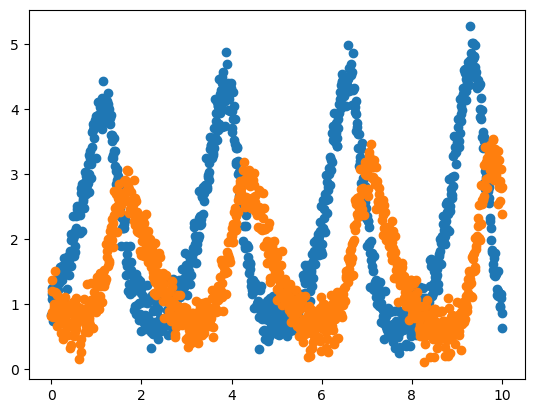

In [ ]:
plt.scatter(data[:, 0], data[:, 1])
plt.scatter(data[:, 0], data[:,2])


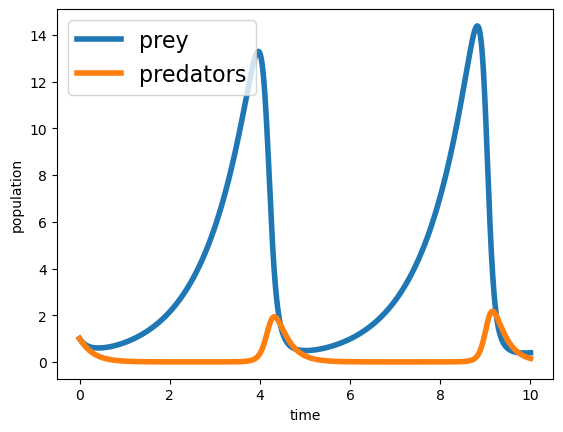

In [ ]:
def parameterise_basic_model(p):
    a, b, c, d = p

    def model(x, t):
        N, P = x
        return [a * x[0] - b * np.prod(x),
                c * np.prod(x) - d * x[1]]

    return model


basic_model = parameterise_basic_model([1, 4, 1, 4])


def solve(f, tspan, x0):
    δt = 0.01
    ts = np.arange(tspan[0], tspan[1] + δt, δt)
    xs = np.zeros((len(x0), len(ts)))
    xs[:, 0] = x0

    for i in range(1, len(ts)):
        xs[:, i] = xs[:, i-1] + δt * np.array(f(xs[:, i-1], ts[i]))

    return ts, xs.T


t_span = (0, 10)
x_0 = np.array([1.0, 1.0])
ts, xs = solve(basic_model, t_span, x_0)

plt.plot(ts, xs[:, 0], label="prey", linewidth=4)
plt.plot(ts, xs[:, 1], label="predators", linewidth=4)
plt.xlabel("time")
plt.ylabel("population")
plt.legend(fontsize=16)

$$
\textbf{Prey Dynamics:}
$$

The prey population dynamics, in the absence of predators (\( P = 0 \)), is modeled as:

$$
\dot{N}(t) = a N(t) \left( 1 - \frac{N(t)}{K} \right)
$$

$$
\textbf{Fixed Points of the Prey Dynamics:}
$$

Fixed points occur when \( \dot{N}(t) = 0 \). Setting \( \dot{N}(t) = 0 \), we get:

$$
a N(t) \left( 1 - \frac{N(t)}{K} \right) = 0
$$

The solutions are:
$$
N(t) = 0 \quad \text{or} \quad N(t) = K
$$

- \( N(t) = 0 \): This corresponds to the extinction of the prey population.
- \($ N(t) = K \): This is the $\textbf{carrying capacity}, the maximum population size the environment can sustain due to resource limitations.

$$
\textbf{Stability of Fixed Points:}
$$

To assess the stability of these fixed points:

1. **For \( N(t) = 0 \):**

   Substitute a small positive perturbation \( \Delta N \):
   $$
   \dot{N}(t) \approx a \Delta N
   $$
   Since \( a > 0 \), the perturbation grows, making \( N(t) = 0 \) an \$xtbf{unsta$e fixed point}.

2. **For \( N(t) = K \):**

   Substitute a small perturbation \( N(t) = K + \Delta N \):
   $$
   \dot{N}(t) \approx a K \left( 1 - \frac{K + \Delta N}{K} \right) = -a \Delta N
   $$
   Since \( -a \Delta N \) restores the population back to \( K \), \( N(t) = K \) is a \textbf{stable fixed point}.

$$
\textbf{Interpretation of Parameter \( K \):}
$$

The parameter \( K \) is the \textbf{carrying capacity} of the environment, representing:

1. The maximum sustainable prey population under the available resources.
2. A measure of the ecosystem's ability to support the prey population.

In the context of predator-prey interactions, \( K \) plays a significant role in determining the long-term dynamics of the prey population in the absence of predators.


# 4E

lets explain the changes :

$\hat{N} = \frac{N}{100}$
$\hat{P} = \frac{P}{10}$


$$\begin{align*}
\frac{d\hat{N}}{dt} &= \frac{1}{100}\frac{dN}{dt} \\
&= \frac{a}{100} N - \frac{b}{100} NP \\
&= a\hat{N} - b\hat{N}\hat{P}
\end{align*}$$


$$\begin{align*}
\frac{d\hat{P}}{dt} &= \frac{1}{10}\frac{dP}{dt} \\
&= \frac{c}{10} NP - \frac{d}{10}P \\
&= c\hat{N}\hat{P} - d\hat{P}
\end{align*}$$

$$\begin{align*}
\frac{d\hat{N}}{dt} &= a\hat{N} - b\hat{N}\hat{P} \\
\frac{d\hat{P}}{dt} &= c\hat{N}\hat{P} - d\hat{P}
\end{align*}$$




The above equation used chain rule to represent the basic model on measuring predators inunits of single animal

# 4F

In [ ]:
def simulation(p):
    """
    Simulates the predator-prey model for the given parameters.
    """
    a, b, c, d = p
    tspan = (0, 10)
    x0 = [1, 1]  # Initial conditions

    def model(x, t):
        N, P = x
        return [a * N - b * N * P, c * N * P - d * P]

    timepoints = np.arange(tspan[0], tspan[1] + 0.01, 0.01)
    result = odeint(model, x0, timepoints)  # Solve ODE
    return result  # Return as a 2D NumPy array


# Example usage:
parameters = [1, 2, 3, 4]  # Replace with your desired parameters
solution = simulation(parameters)
print(solution)


[[1.         1.        ]
 [0.99014949 0.98990281]
 [0.98059584 0.9796224 ]
 ...
 [0.91367181 0.89149938]
 [0.9066476  0.88025257]
 [0.89988015 0.86896788]]


# 4G

In [ ]:
# function for mse
def mse(p, data):
    """
    Calculates the mean squared error between the model simulation and the provided data.
    """
    simulation_result = simulation(p)
    timepoints = np.arange(0, 10.01, 0.01)
    prey_simulated = simulation_result[:, 0]
    predators_simulated = simulation_result[:, 1]


    prey_interpolated = np.interp(data[:, 0], timepoints, prey_simulated)
    predators_interpolated = np.interp(data[:, 0], timepoints, predators_simulated)


    prey_residuals = prey_interpolated - data[:, 1]
    predators_residuals = predators_interpolated - data[:, 2]


    total_residuals = np.concatenate([prey_residuals, predators_residuals])
    mse_value = np.mean(total_residuals**2)

    return mse_value



parameters = [1, 2, 3, 4]
data = np.array([
    [0.0, 1.0, 0.5],
    [0.5, 1.2, 0.7],
    [1.0, 1.5, 1.0],
    [1.5, 1.8, 1.3],
    [2.0, 2.0, 1.5]
])
mse_value = mse(parameters, data)
print("Mean Squared Error:", mse_value)


Mean Squared Error: 0.4662691609039781


# 4F

In [ ]:
def gradient(f, x):
    n = len(x)
    δx = 0.01

    def Δx(i):
        z = np.zeros(n)
        z[i] = δx
        return z

    dfdx = np.zeros(n)
    for i in range(n):
        dfdx[i] = (f(x + Δx(i)) - f(x)) / δx

    return dfdx

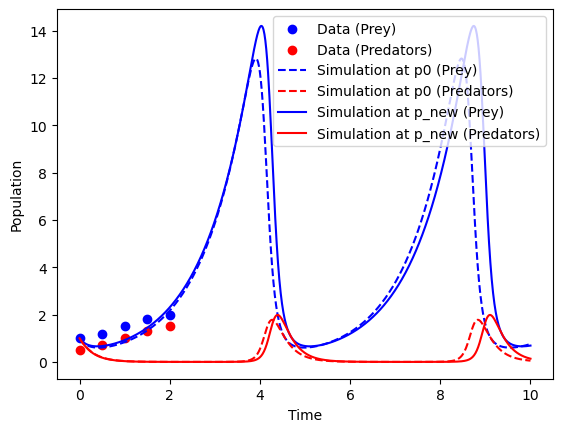

Initial MSE: 0.6384259908580964
Final MSE: 0.6200618258365227
New parameters: [0.95410076 3.61099532 0.92715804 4.08841454]


In [ ]:
def gradient_descent(data, p0, stepsize=0.01, tol=1e-6, max_iters=1000):
    p = np.array(p0, dtype=np.float64)  # Ensure p is a float array
    mse_initial = mse(p, data)

    for _ in range(max_iters):
        grad = gradient(lambda p: mse(p, data), p)
        p -= stepsize * grad
        mse_current = mse(p, data)

        if mse_initial / mse_current >= 3:  # Success condition
            return p, mse_initial, mse_current
        if np.linalg.norm(grad) < tol:  # Convergence condition
            break

    return p, mse_initial, mse(p, data)  # Pass both p and data

# Data (replace with actual dataset)
data = np.array([
    [0.0, 1.0, 0.5],
    [0.5, 1.2, 0.7],
    [1.0, 1.5, 1.0],
    [1.5, 1.8, 1.3],
    [2.0, 2.0, 1.5]
])

# Initial parameters
p0 = [1, 4, 1, 4]

# Run gradient descent
p_new, mse_initial, mse_final = gradient_descent(data, p0)

# Plot comparisons
timepoints = np.arange(0, 10.01, 0.01)
sim_p0 = simulation(p0)
sim_p_new = simulation(p_new)

# Data plots
plt.scatter(data[:, 0], data[:, 1], label="Data (Prey)", color="blue")
plt.scatter(data[:, 0], data[:, 2], label="Data (Predators)", color="red")

# Simulation plots at p0
plt.plot(timepoints, sim_p0[:, 0], label="Simulation at p0 (Prey)", linestyle="--", color="blue")
plt.plot(timepoints, sim_p0[:, 1], label="Simulation at p0 (Predators)", linestyle="--", color="red")

# Simulation plots at p_new
plt.plot(timepoints, sim_p_new[:, 0], label="Simulation at p_new (Prey)", linestyle="-", color="blue")
plt.plot(timepoints, sim_p_new[:, 1], label="Simulation at p_new (Predators)", linestyle="-", color="red")

plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.show()

# Print results
print(f"Initial MSE: {mse_initial}")
print(f"Final MSE: {mse_final}")
print(f"New parameters: {p_new}")


# Question 5

# 5A

$$\begin{align}
\dot{N}_1(t) &= r_1 N_1(t) \left(1 - \frac{N_1(t)}{K_1} - b_{12} \frac{N_2}{K_1} \right) \\
\dot{N}_2(t) &= r_2 N_2(t) \left(1 - \frac{N_2(t)}{K_2} - b_{21} \frac{N_1}{K_2} \right)
\end{align}$$
 = 1.1, \quad \rho = 1.6
$$


When nondimensionalizing the equations, time is rescaled as
$$
𝜏 =
𝑟_1
𝑡
$$
, and population variables are rescaled as
$$
𝑢_1=
𝑁_1
𝐾_1
$$
and
$$
𝑢_2 =
𝑁_2
𝐾_2
$$​
 .

From the nondimensionalized equation for
$𝑢_2$
​
 , we can compare the coefficients and find the relationship between
𝜌 and the original parameters:
$$
𝜌 =
𝑟_2
/
𝑟_1
​$$

​


Biological Interpretation:
Biologically,
𝜌
is the ratio of the intrinsic growth rate of species 2 (
$𝑟_2$
​) to species 1 (
$𝑟_1$):


1) A larger value of
$$
𝜌
(𝜌 >
1 )
$$
 indicates that species 2 grows faster than species 1 in the absence of competition.


2) A smaller value of
 $$
𝜌
(
𝜌
<
1)
$$
indicates that species 2 grows slower than species 1.

# 5B

$$u_1(0) = u_2(0) = 0.1$$
$$a_{12} = 0.9 \quad a_{21} = 1.1 \quad \rho = 1.6$$



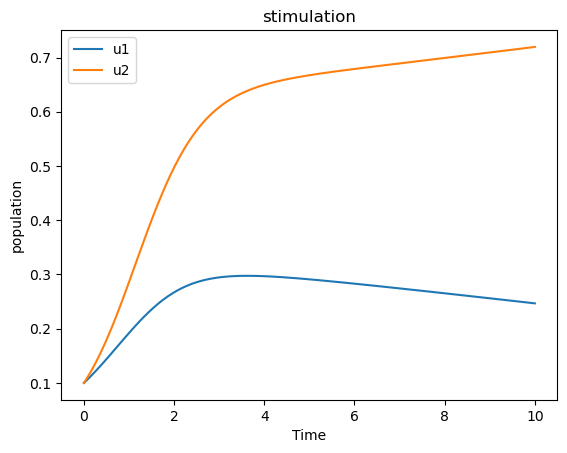

In [ ]:
def function(u,tau,a12,a21,rho):
    du1=u[0]*(1-u[0]-a21*u[1])
    du2=rho*u[1]*(1-u[1]-a21*u[0])
    return [du1,du2]

u0=[0.1,0.1]
a12=0.9
a21=1.1
rho=1.6

tau=np.linspace(0,10,1000)
u= odeint(function,u0,tau,args=(a12, a21 , rho))
plt.plot(tau,u[:,0],label='u1')
plt.plot(tau,u[:,1],label='u2')
plt.xlabel('Time')
plt.ylabel('population')
plt.title('stimulation')
plt.legend()
plt.show()

# 5C

In this model of species competition, the long-term survival of a species appears to be more strongly influenced by its intrinsic growth rate than by the extent of suppression it experiences from its competitor. Simulation results based on the given parameter values indicate that, over an extended period, the species with a higher natural growth rate tends to achieve a larger population size, even when subjected to competition. This highlights the critical role of a species' inherent ability to grow and reproduce in determining its long-term survival, suggesting that intrinsic growth factors may outweigh the effects of inter-species competition.



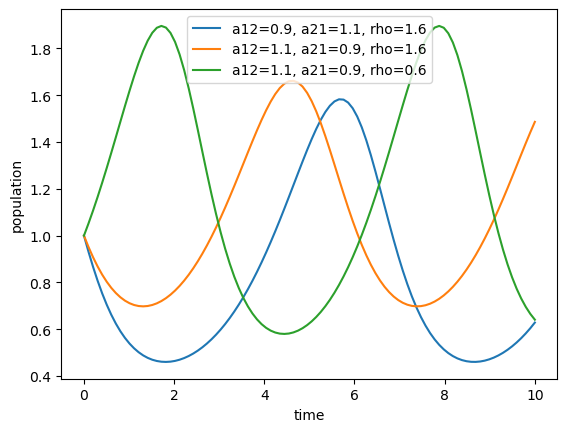

In [ ]:
def Diff_function(u, t, a12, a21, rho):
    c, d= u
    dxdt = a12 * c - rho * c * d
    dydt = a21 * c * d - d
    return [dxdt, dydt]

a12_values = [0.9, 1.1, 1.1]
a21_values = [1.1, 0.9, 0.9]
rho_values = [1.6, 1.6, 0.6]


u0 = [1.0, 1.0]

tau = np.linspace(0, 10, 100)


for a in range(len(a12_values)):
    a12 = a12_values[a]
    a21 = a21_values[a]
    rho = rho_values[a]
    b = odeint(Diff_function, u0, tau, args=(a12, a21, rho))
    plt.plot(tau, b[:, 0], label=f'a12={a12}, a21={a21}, rho={rho}')

plt.xlabel('time')
plt.ylabel('population')
plt.legend()
plt.show()


# 5D

1. **Fixed Point \( (0, 0) \):**
   $$\text{Both species go extinct. This represents a scenario where neither species can sustain itself in the absence of the other or due to environmental constraints.}$$

2. **Fixed Point \( \left( \frac{1}{a_{21}}, 0 \right) \):**
   $$\text{Species 1 (prey) survives at equilibrium, while species 2 (predator) goes extinct. This indicates that species 1 can sustain itself independently, but species 2 relies entirely on species 1 for survival and cannot exist without it.}$$

3. **Fixed Point \( \left( 0, \frac{a_{12}}{\rho} \right) \):**
   $$\text{Species 2 (predator) survives at equilibrium, while species 1 (prey) goes extinct. This is biologically less plausible since predators typically depend on prey for survival. It may represent an artificial scenario where the predator's survival is not dependent on species 1.}$$

4. **Fixed Point \( \left( \frac{1}{a_{21}}, \frac{a_{12}}{\rho} \right) \):**
   $$\text{Both species coexist in equilibrium. The equilibrium population sizes depend on the interaction coefficients \( a_{12}, a_{21}, \rho \). This represents a stable balance between the two species where neither outcompetes the other entirely.}$$
irely.}$$


# 5E

Calculation of Jacobian matrix

Jacobian Matrix

$$J(x)=\begin{bmatrix}
\frac{d\dot{u_1}}{du_1} & \frac{d\dot{u_1}}{du_2}\\
\frac{d\dot{u_2}}{du_1} & \frac{d\dot{u_2}}{du_2}
\end{bmatrix}$$



Derivatives:


$\frac{d\dot{u_1}}{du_1}=1-2u_1-a_{12}u_2$

$\frac{d\dot{u_1}}{du_2}=-u_1a_{12}$

$\dot{u_2}=\rho u_2(1-u_2-a_{21}u_1)$
$\frac{d\dot{u_2}}{du_2}=\rho(1-2u_2-a_{21}u_1)$

$\frac{d\dot{u_2}}{du_1}=-\rho a_{21}u_2$


$$J(x)=\begin{bmatrix}
 1-2u_1-a_{12}u_2 & -u_1a_{12}\\
-\rho a_{21}u_2 & \rho(1-2u_2-a_{21}u_1)
\end{bmatrix}$$


# 5F

### Step 1: Recall the Jacobian Matrix

$$
J(x) =
\begin{bmatrix}
1 - 2u_1 - a_{12}u_2 & -u_1a_{12} \\
-\rho a_{21}u_2 & \rho(1 - 2u_2 - a_{21}u_1)
\end{bmatrix}
$$

---

### Step 2: Fixed Points

The fixed points are determined by setting \(\dot{u_1} = 0\) and \(\dot{u_2} = 0\):

$$
\dot{u_1} = u_1(1 - u_1 - a_{12}u_2) = 0
$$

$$
\dot{u_2} = \rho u_2(1 - u_2 - a_{21}u_1) = 0
$$

The four fixed points are:

1. \((u_1, u_2) = (0, 0)\)
2. \((u_1, u_2) = (1, 0)\)
3. \((u_1, u_2) = (0, 1)\)
4. \((u_1, u_2) = \left(\frac{1 - a_{12}}{1 - a_{12}a_{21}}, \frac{1 - a_{21}}{1 - a_{12}a_{21}}\right)\) (non-trivial fixed point).

---

### Step 3: Evaluate the Jacobian Matrix at Each Fixed Point

#### (a) At \((u_1, u_2) = (0, 0)\):
$$
J(0, 0) =
\begin{bmatrix}
1 & 0 \\
0 & \rho
\end{bmatrix}
$$
The eigenvalues are \(1\) and \(\rho\), both positive. Hence, this fixed point is **unstable**.

#### (b) At \((u_1, u_2) = (1, 0)\):
$$
J(1, 0) =
\begin{bmatrix}
-1 & -a_{12} \\
0 & \rho(1 - a_{21})
\end{bmatrix}
$$
The eigenvalues depend on \(a_{12}\) and \(a_{21}\). For stability:
- \(-1 < 0\), always satisfied.
- \(\rho(1 - a_{21}) < 0 \implies a_{21} > 1\).

#### (c) At \((u_1, u_2) = (0, 1)\):
$$
J(0, 1) =
\begin{bmatrix}
1 - a_{12} & 0 \\
-\rho a_{21} & -\rho
\end{bmatrix}
$$
The eigenvalues depend on \(a_{12}\) and \(a_{21}\). For stability:
- \(1 - a_{12} < 0 \implies a_{12} > 1\).
- \(-\rho < 0\), always satisfied.

#### (d) At \((u_1, u_2) = \left(\frac{1 - a_{12}}{1 - a_{12}a_{21}}, \frac{1 - a_{21}}{1 - a_{12}a_{21}}\right)\):
Substitute the expressions for \(u_1\) and \(u_2\) into the Jacobian matrix:
$$
J(u_1, u_2) =
\begin{bmatrix}
1 - 2u_1 - a_{12}u_2 & -u_1a_{12} \\
-\rho a_{21}u_2 & \rho(1 - 2u_2 - a_{21}u_1)
\end{bmatrix}
$$
The stability depends on the eigenvalues of the resulting matrix, which involve \(\rho\), \(a_{12}\), and \(a_{21}\). For stability, both eigenvalues must have negative real parts.

---

### Step 4: Requirements for Stability

1. For \((1, 0)\): \(a_{21} > 1\)
2. For \((0, 1)\): \(a_{12} > 1\)
3. For the non-trivial fixed point: The stability depends on the eigenvalues of the Jacobian matrix evaluated at this point. Numerical or symbolic computation is required to determine explicit conditions.
